In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d, griddata
from itertools import product
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
import glob
from math import log2
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.cm.get_cmap('RdYlBu')


pd.set_option('display.max_rows', 200)

/tmp/ipykernel_263368/4001252914.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('RdYlBu')


### Load Recast Data

In [2]:
inputFiles = ['/home/ramos/MG5/dmsimpt_pptoxdxd_no_onshell_match/Events/run_08/combined_nocut_cms_exo_20_004.pcl']

dfs = [pd.read_pickle(i) for i in inputFiles]
recastData = pd.concat(dfs, ignore_index=True)

In [ ]:
recastData

,Data-takingperiod,Luminosity (1/fb),bin_250.0_280.0,bin_250.0_280.0_ErrorPlus,bin_250.0_280.0_ErrorMinus,bin_280.0_310.0,bin_280.0_310.0_ErrorPlus,bin_280.0_310.0_ErrorMinus,bin_310.0_340.0,bin_310.0_340.0_ErrorPlus,...,Electronveto,Muonveto,Tauveto,Bjetveto,Photonveto,"$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad",LeadingAK4jet$p_{T}>100$GeV,LeadingAK4jet$\eta<2.4$,HCALmitigation(jets),HCALmitigation($\phi^{miss}$)
0,2016,36.0,6056.726336,355.145200,355.145200,5033.815889,324.647404,324.647404,3596.488426,274.050120,...,0.112080,0.112080,0.108638,0.094812,0.093288,0.093165,0.092001,0.092001,0.092001,0.092001
1,2017,41.5,7249.500361,388.883736,388.883736,5259.909926,330.893387,330.893387,3881.130432,286.106335,...,0.110260,0.110260,0.107237,0.091601,0.090555,0.090323,0.088752,0.088752,0.088752,0.088752
2,2018,59.7,7911.640583,406.636411,406.636411,6203.229336,360.131526,360.131526,4572.970768,309.075567,...,0.113665,0.113665,0.110124,0.093896,0.092458,0.092238,0.090467,0.090467,0.086586,0.075229


In [4]:
recastData.columns

Index(['Data-takingperiod', 'Luminosity (1/fb)', 'bin_250.0_280.0',
       'bin_250.0_280.0_ErrorPlus', 'bin_250.0_280.0_ErrorMinus',
       'bin_280.0_310.0', 'bin_280.0_310.0_ErrorPlus',
       'bin_280.0_310.0_ErrorMinus', 'bin_310.0_340.0',
       'bin_310.0_340.0_ErrorPlus', 'bin_310.0_340.0_ErrorMinus',
       'bin_340.0_370.0', 'bin_340.0_370.0_ErrorPlus',
       'bin_340.0_370.0_ErrorMinus', 'bin_370.0_400.0',
       'bin_370.0_400.0_ErrorPlus', 'bin_370.0_400.0_ErrorMinus',
       'bin_400.0_430.0', 'bin_400.0_430.0_ErrorPlus',
       'bin_400.0_430.0_ErrorMinus', 'bin_430.0_470.0',
       'bin_430.0_470.0_ErrorPlus', 'bin_430.0_470.0_ErrorMinus',
       'bin_470.0_510.0', 'bin_470.0_510.0_ErrorPlus',
       'bin_470.0_510.0_ErrorMinus', 'bin_510.0_550.0',
       'bin_510.0_550.0_ErrorPlus', 'bin_510.0_550.0_ErrorMinus',
       'bin_550.0_590.0', 'bin_550.0_590.0_ErrorPlus',
       'bin_550.0_590.0_ErrorMinus', 'bin_590.0_640.0',
       'bin_590.0_640.0_ErrorPlus', 'bin_590.0_

### Get all model points

In [5]:
models = []
mCols = ['$m_{med}$', '$m_{DM}$', '$\lambda$']
for row in recastData[mCols].values:
    m = dict(zip(mCols, row.tolist()))
    if m not in models:
        models.append(m)

print('%i models loaded.' %len(models))

1 models loaded.


### Get models parameters

In [6]:
parameters = {label : list(set([m[label] for m in models])) for label in mCols}
for k,v in parameters.items():
    if len(v) == 1:
        parameters[k] = v[0]
print(parameters)

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in parameters.items() if k not in ['$m_{med}$','$m_{DM}$']])
print(textstr)

{'$m_{med}$': 300.0, '$m_{DM}$': 200.0, '$\\lambda$': 1.0}
$\lambda$ = 1.0


### Filter parameters

In [7]:
paramFilter = {
    '$m_{med}$' : 300.,
    '$m_{DM}$' : 200.,
    '$\lambda$' : 1.,
    'Data-takingperiod' : 2017
}

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in paramFilter.items()])
dfModel = recastData.loc[(recastData[list(paramFilter)] == pd.Series(paramFilter)).all(axis=1)]

In [8]:
dfModel.T

,1
Data-takingperiod,2017
Luminosity (1/fb),41.5
bin_250.0_280.0,7249.500361
bin_250.0_280.0_ErrorPlus,388.883736
bin_250.0_280.0_ErrorMinus,388.883736
bin_280.0_310.0,5259.909926
bin_280.0_310.0_ErrorPlus,330.893387
bin_280.0_310.0_ErrorMinus,330.893387
bin_310.0_340.0,3881.130432
bin_310.0_340.0_ErrorPlus,286.106335


The efficiency for the $i$-th bin, $\epsilon_{i}$, is given by:

$$ \epsilon_{i} = \frac{n^{i}_{s}}{\sigma_{T}\mathcal{L}},   $$
where $n^{i}_{s}$ is the number of events in the correspondent bin, $\sigma_{T}$ is the total cross-section, and $\mathcal{L}$ is the integrated luminosity.  

### Auxiliar functions for plotting

In [9]:
def getBins(dfModel,rightBin = 1400.):
    
    bins = {c : eval(c.split('_')[1]) for c in dfModel.columns if ("bin_" in c and not 'Error' in c)}
    binsError = {c : eval(c.split('_')[1]) for c in dfModel.columns if ("bin_" in c and 'ErrorPlus' in c)}    
    binCenter = (np.array(list(bins.values()))+np.diff(list(bins.values())+[rightBin])/2).tolist()    
    binLeft = [bins[c] for c in bins]+[rightBin] 
    
    return bins,binsError,binCenter,binLeft


def getEfficiencies(dfSingle, bins, binsError):
    
    xsec = dfSingle['Total xsec-pT150 (pb)'].iloc[0]
    lumi = dfSingle['Luminosity (1/fb)'].iloc[0]
    eff = {}
    ns = {c: dfSingle[c].iloc[0] for c in bins}
    nsErr = {c : dfSingle[c].iloc[0] for c in binsError}
    effErr = {}
    for c in bins:
        if ns[c] == 0:
            eff[c] = 0
            effErr[f'{c}_Error'] = 0
        else:
            eff[c] = dfSingle[c].iloc[0]/(xsec*1e3*lumi)
            effErr[f'{c}_Error'] = nsErr[f'{c}_ErrorPlus']*eff[c]/ns[c]
    
    return eff, effErr

### Plot Efficiencies

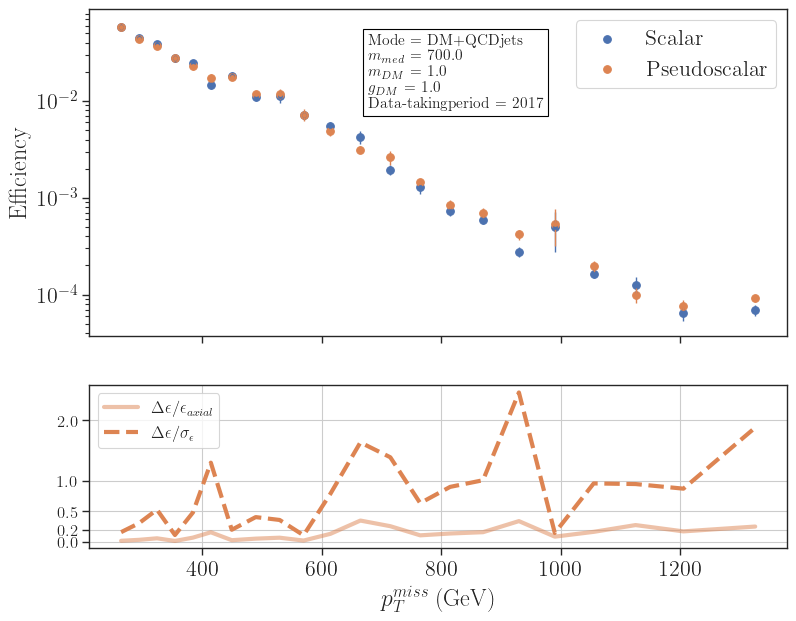

In [ ]:
bins, binsError, binCenter, binLeft = getBins(dfModel)

fig, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2, 1]},figsize=(9,7))


data = pd.DataFrame(columns=['Scalar', 'Pseudoscalar'])
dataError = pd.DataFrame(columns=['Scalar', 'Pseudoscalar'])

colors = {label : sns.color_palette('deep')[i] for i,label in enumerate(data.keys())}    

for label in dfModel['Coupling']:
    dfSingle = dfModel[dfModel['Coupling'] == label]
    data[label], dataError[label] = getEfficiencies(dfSingle, bins, binsError)
 
    eff = np.array([data[label][c] for c in bins])
    effErr = np.array([dataError[label][f'{c}_Error'] for c in bins])
    
    ax[0].scatter(x=binCenter, y=eff, s=30, color=colors[label], label=label)
    ax[0].errorbar(binCenter, eff, yerr=effErr, marker='.', 
                   elinewidth=1.0, drawstyle='steps-mid',linewidth=0.0, color=colors[label])

# diff = np.abs(data.Axial - data.Vector)

diff = np.abs(data.Pseudoscalar - data.Scalar)

# relDiff = diff/data.Axial
relDiff = diff/data.Pseudoscalar

relDiff = relDiff.replace(np.nan, 0)

# diffError = np.array(diff)/np.sqrt(dataError.Axial**2 + dataError.Vector**2)
# diffError = diffError.replace(np.nan, 0)
diffError = np.array(diff)/np.sqrt(dataError.Pseudoscalar**2 + dataError.Scalar**2)
diffError = diffError.replace(np.nan, 0)

label1 = r'$\Delta \epsilon / \epsilon_{axial}$'
# label1 = r'$\frac{\mbox{Axial-Vector}}{\mbox{Axial}}$'
label2 = r'$\Delta \epsilon / \sigma_{\epsilon}$'

ax[1].plot(binCenter, relDiff, color=colors[label], linewidth=3., label=label1, alpha=.5)
ax[1].plot(binCenter, diffError, color=colors[label], linewidth=3., linestyle='--', 
           label=label2)

    
ax[0].set_yscale('log')
ax[0].text(.4, 2.7, textstr, fontsize=11, bbox=dict(facecolor='none', edgecolor='black'), 
           transform=plt.gca().transAxes)



ax[0].set_ylabel('Efficiency')
ax[0].legend()

# ax[1].set_ylim(0., 2.)
ax[1].legend(fontsize='12')
ax[1].grid(True)
ax[1].set_yticks([0., 0.2, 0.5, 1., 2.])
ax[1].tick_params(axis='y', labelsize='12')
ax[1].set_xlabel(r'$p_{T}^{miss}$ (GeV)')
# ax[1].set_ylabel('Relative diff.')

plt.show()

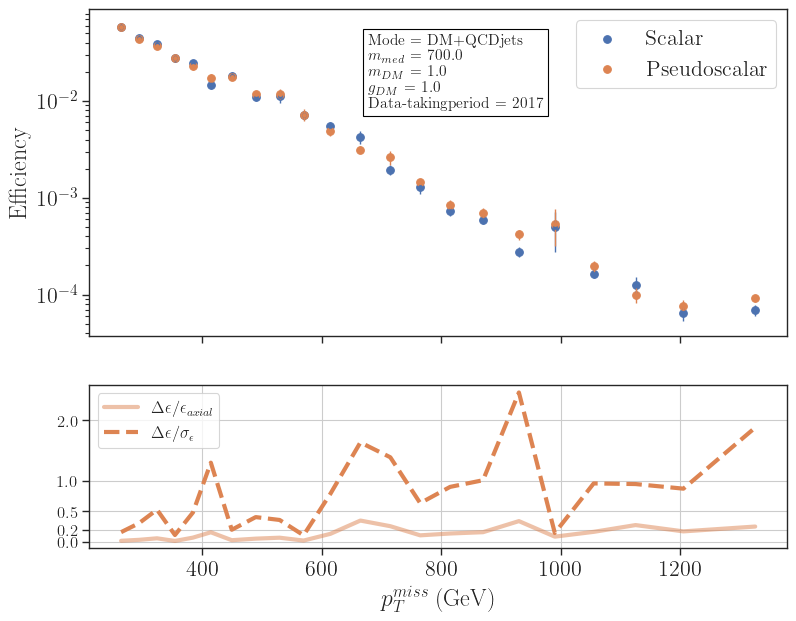

In [10]:
bins, binsError, binCenter, binLeft = getBins(dfModel)

fig, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2, 1]},figsize=(9,7))

# data = pd.DataFrame(columns=['Axial', 'Vector'])
# dataError = pd.DataFrame(columns=['Axial', 'Vector'])

data = pd.DataFrame(columns=['Scalar', 'Pseudoscalar'])
dataError = pd.DataFrame(columns=['Scalar', 'Pseudoscalar'])

colors = {label : sns.color_palette('deep')[i] for i,label in enumerate(data.keys())}    

for label in dfModel['Coupling']:
    dfSingle = dfModel[dfModel['Coupling'] == label]
    data[label], dataError[label] = getEfficiencies(dfSingle, bins, binsError)
 
    eff = np.array([data[label][c] for c in bins])
    effErr = np.array([dataError[label][f'{c}_Error'] for c in bins])
    
    ax[0].scatter(x=binCenter, y=eff, s=30, color=colors[label], label=label)
    ax[0].errorbar(binCenter, eff, yerr=effErr, marker='.', 
                   elinewidth=1.0, drawstyle='steps-mid',linewidth=0.0, color=colors[label])

# diff = np.abs(data.Axial - data.Vector)

diff = np.abs(data.Pseudoscalar - data.Scalar)

# relDiff = diff/data.Axial
relDiff = diff/data.Pseudoscalar

relDiff = relDiff.replace(np.nan, 0)

# diffError = np.array(diff)/np.sqrt(dataError.Axial**2 + dataError.Vector**2)
# diffError = diffError.replace(np.nan, 0)
diffError = np.array(diff)/np.sqrt(dataError.Pseudoscalar**2 + dataError.Scalar**2)
diffError = diffError.replace(np.nan, 0)

label1 = r'$\Delta \epsilon / \epsilon_{axial}$'
# label1 = r'$\frac{\mbox{Axial-Vector}}{\mbox{Axial}}$'
label2 = r'$\Delta \epsilon / \sigma_{\epsilon}$'

ax[1].plot(binCenter, relDiff, color=colors[label], linewidth=3., label=label1, alpha=.5)
ax[1].plot(binCenter, diffError, color=colors[label], linewidth=3., linestyle='--', 
           label=label2)

    
ax[0].set_yscale('log')
ax[0].text(.4, 2.7, textstr, fontsize=11, bbox=dict(facecolor='none', edgecolor='black'), 
           transform=plt.gca().transAxes)



ax[0].set_ylabel('Efficiency')
ax[0].legend()

# ax[1].set_ylim(0., 2.)
ax[1].legend(fontsize='12')
ax[1].grid(True)
ax[1].set_yticks([0., 0.2, 0.5, 1., 2.])
ax[1].tick_params(axis='y', labelsize='12')
ax[1].set_xlabel(r'$p_{T}^{miss}$ (GeV)')
# ax[1].set_ylabel('Relative diff.')

plt.show()